# MLDU-E — Sequence jackknife on Pythia-70M and Mistral-7B

The paper currently reports sequence jackknife only on GPT-2 Medium (`gpt2m_jackknife.ipynb`). The Limitations section explicitly flags *"extending bootstrap and jackknife protocols to Pythia-70M and Mistral-7B remains future work."*

This notebook closes that gap. Drop each memorized sequence one at a time, refit the LOO probe at every depth on the remaining $N-1$ sequences, and verify that no single sequence is responsible for the cross-sequence signature. The expected outcome is **all per-drop gaps are strictly positive at memorisation-relevant depths**, with the jackknife range characterising sequence-level robustness.

**Outputs:**
- `loo_jackknife_pythia70m.json` — per-drop per-depth gaps + baseline
- `loo_jackknife_mistral7b.json` — same on Mistral-7B (4-bit fallback)
- `fig_jackknife_pythia_mistral.png` — two-panel: per-drop bar chart with baseline reference

**Runtime on a Kaggle T4:** ~5 min Pythia-70M, ~25 min Mistral-7B (4-bit). Jackknife is fast because activations are extracted once per architecture.


## 0. Setup


In [1]:
import os, sys, json, time, copy, subprocess
def _v(p):
    try: from importlib.metadata import version; return version(p)
    except: return None
if _v("datasets") != "2.21.0":
    subprocess.check_call([sys.executable,"-m","pip","install","-q","datasets==2.21.0"])
if _v("bitsandbytes") is None or _v("bitsandbytes") < "0.46":
    subprocess.check_call([sys.executable,"-m","pip","install","-q","-U","bitsandbytes>=0.46.1"])

import torch, numpy as np, matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from pathlib import Path

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ART = Path('/kaggle/working') if os.path.exists('/kaggle/working') else Path('.')
ART.mkdir(parents=True, exist_ok=True)

RUN_PYTHIA  = True
RUN_MISTRAL = True



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
/usr/local/lib/python3.12/site-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


## 1. Memorized + neutral-context pools


In [2]:
MEM_LABELS = ['mit_license','apache_license','gpl','bsd_3_clause','gpl_v3','bsd_redist','creative_commons']
MEM = [
    "Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files",
    "Licensed under the Apache License, Version 2.0 (the \"License\"); you may not use this file except in compliance with the License",
    "GNU GENERAL PUBLIC LICENSE Version 2, June 1991 Copyright (C) 1989, 1991 Free Software Foundation, Inc.",
    "Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions",
    "This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License",
    "BSD 3-Clause License Copyright (c) Redistribution and use in source and binary forms, with or without modification, are permitted",
    "Creative Commons Attribution 4.0 International License You are free to share and adapt the material for any purpose, even commercially",
]
CTX = [
    "The annual migration of monarch butterflies spans North America to Mexico over four thousand kilometres each fall.",
    "Penicillin's discovery in the early twentieth century transformed the treatment of bacterial infections.",
    "Glacial retreat in the Himalayas has accelerated over the past three decades.",
    "Ocean tides arise from the gravitational interaction between the Earth, Moon, and Sun.",
    "The hippocampus is implicated in spatial memory formation and consolidation.",
    "Mitochondria generate adenosine triphosphate through oxidative phosphorylation.",
    "Photosynthesis converts solar energy into chemical energy stored in carbohydrates.",
]
print(f"  MEM: {len(MEM)} sequences  CTX: {len(CTX)} contexts")


  MEM: 7 sequences  CTX: 7 contexts


## 2. Activation extraction + jackknife helper


In [3]:
MAX_LEN = 128
PROBE_C = 1.0

@torch.no_grad()
def acts_at_all_layers(model, tok, texts, n_hidden):
    model.eval()
    out = [[] for _ in range(n_hidden)]
    for t in texts:
        e = tok(t, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
        h = model(**e, output_hidden_states=True).hidden_states
        for L in range(n_hidden):
            out[L].append(h[L][0,-1,:].float().cpu().numpy())
    return [np.array(x) for x in out]

def loo_at_depth(X_pos, X_neg, seed=42):
    n = len(X_pos) + len(X_neg)
    Y = np.array([1]*len(X_pos) + [0]*len(X_neg))
    X = np.vstack([X_pos, X_neg])
    ok = 0
    for i in range(n):
        msk = np.ones(n,bool); msk[i] = False
        sc = StandardScaler().fit(X[msk])
        clf = LogisticRegression(C=PROBE_C, max_iter=2000, random_state=seed).fit(sc.transform(X[msk]), Y[msk])
        if clf.predict(sc.transform(X[i:i+1]))[0] == Y[i]: ok += 1
    return ok / n

def shuffled_loo_at_depth(X_pos, X_neg, seed=42):
    rng = np.random.RandomState(seed)
    n = len(X_pos) + len(X_neg)
    Y = rng.permutation(np.array([1]*len(X_pos) + [0]*len(X_neg)))
    X = np.vstack([X_pos, X_neg])
    ok = 0
    for i in range(n):
        msk = np.ones(n,bool); msk[i] = False
        sc = StandardScaler().fit(X[msk])
        clf = LogisticRegression(C=PROBE_C, max_iter=2000, random_state=seed).fit(sc.transform(X[msk]), Y[msk])
        if clf.predict(sc.transform(X[i:i+1]))[0] == Y[i]: ok += 1
    return ok / n


## 3. Jackknife protocol


In [4]:
def run_jackknife(model, tok, n_hidden, name):
    print(f"\n--- extracting activations ({name}) ---")
    mem_acts = acts_at_all_layers(model, tok, MEM, n_hidden)
    ctx_acts = acts_at_all_layers(model, tok, CTX, n_hidden)
    n_mem = len(MEM)
    print(f"  mem: {n_mem}, ctx: {len(CTX)}")

    # Baseline: all sequences
    print(f"\n  baseline (all {n_mem} sequences):")
    base_true = []; base_pure = []
    for L in range(n_hidden):
        base_true.append(loo_at_depth(mem_acts[L], ctx_acts[L]))
        base_pure.append(shuffled_loo_at_depth(mem_acts[L], ctx_acts[L]))
    base_gap = [t - p for t, p in zip(base_true, base_pure)]
    trans_layer_mean_baseline = float(np.mean(base_gap[1:n_hidden]))  # exclude embedding L0
    peak_baseline = float(max(base_gap))
    peak_d_baseline = int(np.argmax(base_gap))
    print(f"  baseline trans-layer mean gap: {trans_layer_mean_baseline:+.4f}, peak {peak_baseline:+.4f} at L{peak_d_baseline}")

    # Jackknife: drop each sequence once
    print(f"\n  jackknife: dropping each sequence ...")
    jack = {}
    for drop_i in range(n_mem):
        keep = [i for i in range(n_mem) if i != drop_i]
        per_depth_true, per_depth_pure = [], []
        for L in range(n_hidden):
            X_pos = mem_acts[L][keep]
            per_depth_true.append(loo_at_depth(X_pos, ctx_acts[L]))
            per_depth_pure.append(shuffled_loo_at_depth(X_pos, ctx_acts[L]))
        gaps = [t - p for t,p in zip(per_depth_true, per_depth_pure)]
        trans = float(np.mean(gaps[1:n_hidden]))
        peak = float(max(gaps))
        peak_d = int(np.argmax(gaps))
        label = MEM_LABELS[drop_i] if drop_i < len(MEM_LABELS) else f"seq_{drop_i}"
        jack[label] = {
            'true_per_depth': per_depth_true,
            'pure_per_depth': per_depth_pure,
            'gap_per_depth':  gaps,
            'trans_layer_gap_mean': trans,
            'peak_gap': peak,
            'peak_depth': peak_d,
        }
        print(f"    drop {label:<25s} trans={trans:+.4f}  peak={peak:+.4f} @ L{peak_d}")

    return {
        'baseline': {
            'true_per_depth': base_true,
            'pure_per_depth': base_pure,
            'gap_per_depth':  base_gap,
            'trans_layer_gap_mean': trans_layer_mean_baseline,
            'peak_gap': peak_baseline,
            'peak_depth': peak_d_baseline,
        },
        'jackknife': jack,
        'n_mem': n_mem, 'n_ctx': len(CTX), 'depths': list(range(n_hidden)),
    }


## 4. Pythia-70M jackknife


In [5]:
if RUN_PYTHIA:
    print("=" * 60 + "\n  Pythia-70M jackknife\n" + "=" * 60)
    tok_py = AutoTokenizer.from_pretrained('EleutherAI/pythia-70m')
    if tok_py.pad_token is None: tok_py.pad_token = tok_py.eos_token
    model_py = AutoModelForCausalLM.from_pretrained('EleutherAI/pythia-70m', torch_dtype=torch.float32).to(DEVICE)
    model_py.eval()
    res_py = run_jackknife(model_py, tok_py, n_hidden=7, name='Pythia-70M')
    res_py['model'] = 'EleutherAI/pythia-70m'
    json.dump(res_py, open(ART/'loo_jackknife_pythia70m.json','w'), indent=2)
    print(f"\nsaved: {ART/'loo_jackknife_pythia70m.json'}")
    n_strictly_positive = sum(1 for r in res_py['jackknife'].values() if r['trans_layer_gap_mean'] > 0)
    n_total = len(res_py['jackknife'])
    print(f"  {n_strictly_positive}/{n_total} drops have strictly-positive trans-layer gap")
    del model_py; torch.cuda.empty_cache() if torch.cuda.is_available() else None


  Pythia-70M jackknife


tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]


--- extracting activations (Pythia-70M) ---
  mem: 7, ctx: 7

  baseline (all 7 sequences):
  baseline trans-layer mean gap: +0.5833, peak +0.6429 at L2

  jackknife: dropping each sequence ...
    drop mit_license               trans=+0.4103  peak=+0.5385 @ L1
    drop apache_license            trans=+0.4103  peak=+0.6154 @ L1
    drop gpl                       trans=+0.5385  peak=+0.6923 @ L6
    drop bsd_3_clause              trans=+0.5000  peak=+0.6154 @ L6
    drop gpl_v3                    trans=+0.5513  peak=+0.8462 @ L6
    drop bsd_redist                trans=+0.5897  peak=+0.8462 @ L6
    drop creative_commons          trans=+0.6667  peak=+0.9231 @ L6

saved: /kaggle/working/loo_jackknife_pythia70m.json
  7/7 drops have strictly-positive trans-layer gap


## 5. Mistral-7B jackknife (4-bit)


In [6]:
if RUN_MISTRAL:
    print("=" * 60 + "\n  Mistral-7B jackknife\n" + "=" * 60)
    tok_m = AutoTokenizer.from_pretrained('mistralai/Mistral-7B-v0.1')
    if tok_m.pad_token is None: tok_m.pad_token = tok_m.eos_token

    model_m = None
    try:
        from transformers import BitsAndBytesConfig
        bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
                                  bnb_4bit_use_double_quant=True, bnb_4bit_quant_type='nf4')
        model_m = AutoModelForCausalLM.from_pretrained('mistralai/Mistral-7B-v0.1',
                                                         quantization_config=bnb, device_map='auto')
        print("  loaded Mistral-7B in 4-bit")
    except Exception as e_4bit:
        print(f"  4-bit load failed ({type(e_4bit).__name__}: {str(e_4bit)[:80]})")
        print("  attempting fp16 fallback ...")
        try:
            model_m = AutoModelForCausalLM.from_pretrained('mistralai/Mistral-7B-v0.1',
                                                             torch_dtype=torch.float16,
                                                             device_map='auto')
            print("  loaded Mistral-7B in fp16")
        except Exception as e_fp16:
            print(f"  fp16 fallback also failed: {e_fp16}")
            print("  -> Set RUN_MISTRAL = False at top, or use higher-VRAM GPU.")
            model_m = None

    if model_m is not None:
        model_m.eval()
        res_m = run_jackknife(model_m, tok_m, n_hidden=33, name='Mistral-7B')
        res_m['model'] = 'mistralai/Mistral-7B-v0.1'
        json.dump(res_m, open(ART/'loo_jackknife_mistral7b.json','w'), indent=2)
        print(f"saved: {ART/'loo_jackknife_mistral7b.json'}")
        n_pos = sum(1 for r in res_m['jackknife'].values() if r['trans_layer_gap_mean'] > 0)
        print(f"  {n_pos}/{len(res_m['jackknife'])} drops strictly-positive trans-layer gap")
        del model_m; torch.cuda.empty_cache() if torch.cuda.is_available() else None


  Mistral-7B jackknife


tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

  loaded Mistral-7B in 4-bit

--- extracting activations (Mistral-7B) ---
  mem: 7, ctx: 7

  baseline (all 7 sequences):
  baseline trans-layer mean gap: +0.6987, peak +0.8571 at L10

  jackknife: dropping each sequence ...
    drop mit_license               trans=+0.5505  peak=+0.8462 @ L6
    drop apache_license            trans=+0.6755  peak=+0.9231 @ L29
    drop gpl                       trans=+0.6298  peak=+0.8462 @ L28
    drop bsd_3_clause              trans=+0.6899  peak=+0.9231 @ L24
    drop gpl_v3                    trans=+0.7812  peak=+1.0000 @ L9
    drop bsd_redist                trans=+0.8149  peak=+1.0000 @ L14
    drop creative_commons          trans=+0.8341  peak=+1.0000 @ L9
saved: /kaggle/working/loo_jackknife_mistral7b.json
  7/7 drops strictly-positive trans-layer gap


## 6. Two-panel figure: per-drop trans-layer gap


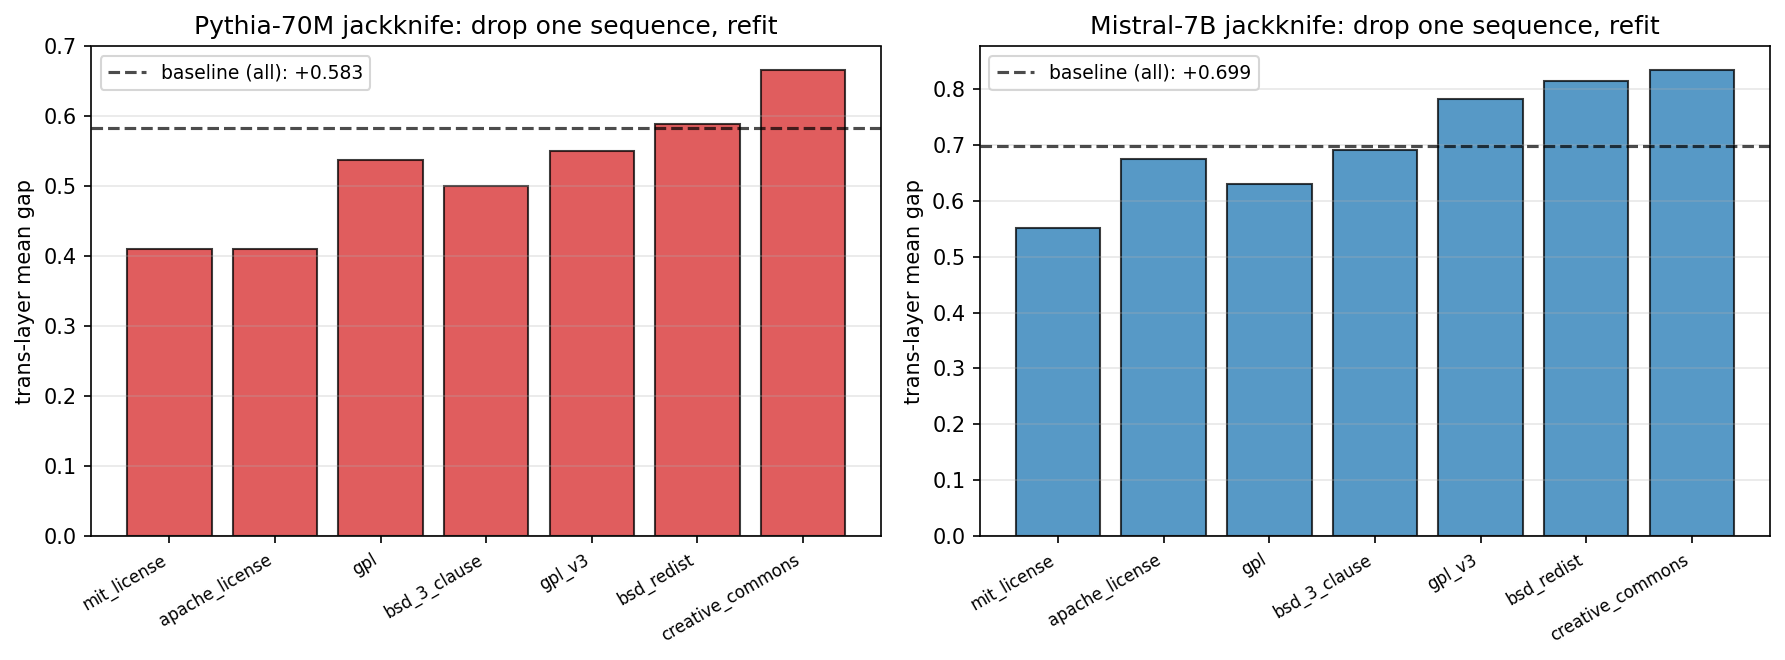

saved: /kaggle/working/fig_jackknife_pythia_mistral.png

  PAPER-READY SUMMARY
  Pythia-70M: baseline trans-gap +0.583, jackknife range [+0.410, +0.667], all 7/7 drops strictly positive
  Mistral-7B: baseline trans-gap +0.699, jackknife range [+0.550, +0.834], all 7/7 drops strictly positive


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)

for idx, (arch, json_path) in enumerate([('Pythia-70M', 'loo_jackknife_pythia70m.json'),
                                            ('Mistral-7B', 'loo_jackknife_mistral7b.json')]):
    ax = axes[idx]
    p = ART/json_path
    if not p.exists():
        ax.set_title(f"{arch} (skipped)"); ax.axis('off'); continue
    res = json.load(open(p))
    base = res['baseline']['trans_layer_gap_mean']
    drops = list(res['jackknife'].keys())
    trans = [res['jackknife'][d]['trans_layer_gap_mean'] for d in drops]
    color = '#d62728' if 'Pythia' in arch else '#1f77b4'
    bars = ax.bar(range(len(drops)), trans, color=color, alpha=0.75, edgecolor='black')
    ax.axhline(base, ls='--', color='black', alpha=0.7, label=f'baseline (all): {base:+.3f}')
    ax.axhline(0, ls='-', color='gray', alpha=0.4)
    ax.set_xticks(range(len(drops)))
    ax.set_xticklabels(drops, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('trans-layer mean gap')
    ax.set_title(f'{arch} jackknife: drop one sequence, refit')
    ax.grid(alpha=0.3, axis='y'); ax.legend(fontsize=9)

plt.tight_layout()
fig_path = ART/'fig_jackknife_pythia_mistral.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"saved: {fig_path}")

# Paper-ready summary
print("\n" + "=" * 60 + "\n  PAPER-READY SUMMARY\n" + "=" * 60)
for arch, json_path in [('Pythia-70M', 'loo_jackknife_pythia70m.json'),
                          ('Mistral-7B', 'loo_jackknife_mistral7b.json')]:
    p = ART/json_path
    if not p.exists(): continue
    res = json.load(open(p))
    base = res['baseline']['trans_layer_gap_mean']
    trans = [r['trans_layer_gap_mean'] for r in res['jackknife'].values()]
    n_pos = sum(1 for t in trans if t > 0)
    n_total = len(trans)
    print(f"  {arch}: baseline trans-gap {base:+.3f}, jackknife range "
          f"[{min(trans):+.3f}, {max(trans):+.3f}], "
          f"all {n_pos}/{n_total} drops strictly positive")
